# **________ AT&T project ________** #

*The goal of this project is to build a spam detector, that can automatically flag spams as they come based solely on the sms' content.*

## **I. EDA**

###  **0. Configuration & Drive setup**

The following code performs setup actions that are necessary for every session:



* **drive.mount():** Connects Drive to the temporary Colab machine.
* **os.chdir(PROJECT_PATH)**: Moves Python session into the project folder.
* **sys.path.append('src'):** Allows us to import our .py files (for instance : custumed functions).

This cell must be run in the first cell of every notebook, every time a session is started.

In [56]:
#  --------------  CODE TO MOUNT DRIVE AND SET WORKING DIRECTORY   --------------

from google.colab import drive
import os

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Define your project path
PROJECT_PATH = '/content/drive/MyDrive/Colab_Projects/AT-T_project'

# 3. Change current directory to the project path
os.chdir(PROJECT_PATH)

# 4. Add the 'src' directory to Python's system path

import sys
if 'src' not in sys.path:
    sys.path.append('src')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


###  **1. Libraries import**

In [57]:
import io
import os
import re
import shutil
import tarfile
import string

import tiktoken
import requests
import numpy as np
import pandas as pd

# ===================== VISUALISATION =====================
import matplotlib.pyplot as plt
import seaborn as sns

# ======== NLP (Natural Language Processing) ========
from collections import Counter
from wordcloud import WordCloud

# ======== DEEP LEARNING ========
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split

device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device.")

Using cpu device.


### **2. Data import & general information on the dataset**

In [58]:
raw_df=pd.read_csv('./DATA/DATA_raw/spam.csv',encoding='latin-1')

# The file contains some specific characters that are not valid under the
# utf-8 encoding scheme so we select the 'latin-1 encoding that covers all 256 byte values.

raw_df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [59]:
raw_df.shape

(5572, 5)

In [60]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [61]:
raw_df.describe(include='all')

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
count,5572,5572,50,12,6
unique,2,5169,43,10,5
top,ham,"Sorry, I'll call later","bt not his girlfrnd... G o o d n i g h t . . .@""","MK17 92H. 450Ppw 16""","GNT:-)"""
freq,4825,30,3,2,2


This dataset contains 5 columns but only the first 2 ones will be used for this analysis. Indeed the last 3 ones contains to many NaN to have a significant meaning.

### **3. Data cleaning**

Dropping useless columns and renaming the other ones :

In [62]:
df = raw_df.rename(columns={'v1': 'label', 'v2': 'message'})
df = df[['label', 'message']]

Check for duplicated rows:

In [63]:
duplicates = df.duplicated().sum()
print(f"There are : {duplicates} duplicated rows, this represents {round((100*duplicates/df.shape[0]),2)} % of the dataset.")

There are : 403 duplicated rows, this represents 7.23 % of the dataset.


Approximately 7.2% of the dataset is identified as duplicated. We are going to deeper investigate these duplicates :


In [64]:
# We select and order the duplicated rows:

df[df.duplicated(keep=False)].sort_values(by=["label", "message"])

,label,message
1372,ham,1) Go to write msg 2) Put on Dictionary mode 3...
2162,ham,1) Go to write msg 2) Put on Dictionary mode 3...
2343,ham,1) Go to write msg 2) Put on Dictionary mode 3...
1469,ham,7 wonders in My WORLD 7th You 6th Ur style 5th...
1778,ham,7 wonders in My WORLD 7th You 6th Ur style 5th...
...,...,...
5035,spam,You won't believe it but it's true. It's Incre...
2832,spam,You've won tkts to the EURO2004 CUP FINAL or å...
3003,spam,You've won tkts to the EURO2004 CUP FINAL or å...
95,spam,Your free ringtone is waiting to be collected....


In [65]:
# We check that every duplicate has only one label (not both ham and spam)

df.groupby("message")["label"].nunique().value_counts()

,count
label,
1,5169


The results confirmed that there are no inconsistencies (i.e., no message labeled both as spam and ham).

In the context of natural language processing, keeping duplicated messages may introduce bias by over-representing certain texts, which can lead to overfitting and reduced generalization performance.

Therefore, we decided to remove duplicates based on the message content, keeping only unique messages in the dataset. This approach helps improve model robustness and ensures a more balanced representation of the textual data.

In [66]:
df = df.drop_duplicates(subset=["message"])

In [67]:
print(f"{len(raw_df)-len(df)} rows have been dropped.")

403 rows have been dropped.


In [68]:
print(f"The cleaned dataset has : {df.shape[0]} rows and {df.shape[1]} columns.")

The cleaned dataset has : 5169 rows and 2 columns.


### **4. Class Distribution**

***1. Class distribution of the target***

In [69]:
distribution = round(100 * df['label'].value_counts(normalize=True),2)
distribution

,proportion
label,
ham,87.37
spam,12.63


We can notice that our target variable (spam or non-spam) is **imbalanced.** It means that for evaluating our models we are going to focus more on Precision, Recall, and F1-score rather than just Accuracy. Moreover, we will potentially require sampling techniques (like oversampling (SMOTE)) or undersampling).

***2. Label Encoding***

For Machine Learning, we need to convert labels into numbers:

In [70]:
# 0 -> represents the non spam class 'ham'
# 1 -> represents the spam class  `spam`

In [71]:
df['encoded_label'] = df['label'].map({'ham': 0, 'spam': 1})

In [72]:
df.head(10)

,label,message,encoded_label
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0
5,spam,FreeMsg Hey there darling it's been 3 week's n...,1
6,ham,Even my brother is not like to speak with me. ...,0
7,ham,As per your request 'Melle Melle (Oru Minnamin...,0
8,spam,WINNER!! As a valued network customer you have...,1
9,spam,Had your mobile 11 months or more? U R entitle...,1


### **5. Message length analysis**

We are now going to check if the spam messages have specific patters. First, we will check the lenght of messages. Are spams shorter? Longer? Is there a significant difference? We can check two kind of lenghts : the number of total characters in the message and the number of words.

In [73]:
# Number of characters in the messages :
df['nb_chars'] = df['message'].apply(len)

# Number of words in the messages
df['nb_words'] = df['message'].apply(lambda x: len(x.split()))

In [74]:
df.head(5)

,label,message,encoded_label,nb_chars,nb_words
0,ham,"Go until jurong point, crazy.. Available only ...",0,111,20
1,ham,Ok lar... Joking wif u oni...,0,29,6
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1,155,28
3,ham,U dun say so early hor... U c already then say...,0,49,11
4,ham,"Nah I don't think he goes to usf, he lives aro...",0,61,13


In [75]:
ham_df = df[df['label'] == 'ham'].copy()
spam_df = df[df['label'] == 'spam'].copy()

In [76]:
ham_df.describe(exclude = object)

,encoded_label,nb_chars,nb_words
count,4516.0,4516.000000,4516.000000
mean,0.0,70.459256,14.134632
std,0.0,56.358207,11.116240
min,0.0,2.000000,1.000000
25%,0.0,34.000000,7.000000
50%,0.0,52.000000,11.000000
75%,0.0,90.000000,18.000000
max,0.0,910.000000,171.000000


In [77]:
spam_df.describe(exclude = object)

,encoded_label,nb_chars,nb_words
count,653.0,653.000000,653.000000
mean,1.0,137.891271,23.681470
std,0.0,30.137753,5.967672
min,1.0,13.000000,2.000000
25%,1.0,132.000000,22.000000
50%,1.0,149.000000,25.000000
75%,1.0,157.000000,28.000000
max,1.0,224.000000,35.000000


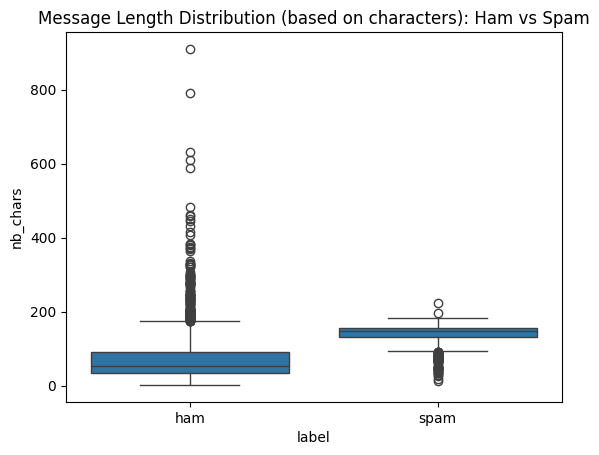

In [78]:
sns.boxplot(x="label", y="nb_chars", data=df)

plt.title("Message Length Distribution (based on characters)")
plt.show()

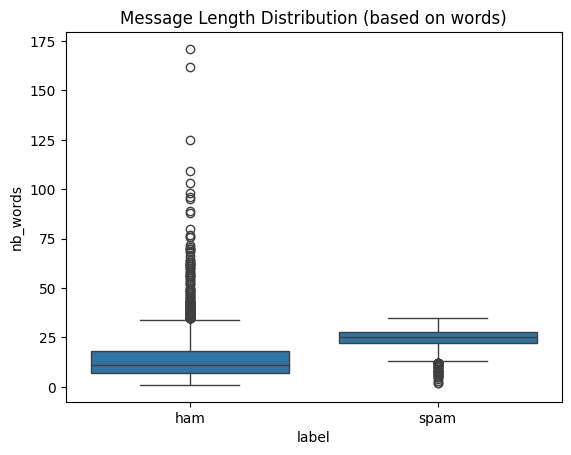

In [80]:
sns.boxplot(x="label", y="nb_words", data=df)

plt.title("Message Length Distribution (based on words)")
plt.show()

The boxplots suggests a difference in the lenghts of spam messages that seems to be longer. We need to validate this difference using a statistic test.

### **6. Word frequency analysis**

### **7. Special characters analysis**

## **III. PREPROCESSING**

## **IV. MODELIZATION**

## **V. EVALUATION**